# Pruebas del clasificador de Pokémon

Carga los modelos entrenados y predice el Pokémon de cada imagen (no entrena).

Incluye una comparación **antes vs después de las mejoras** sobre las imágenes que se probaron con el
profesor (`pruebasBenji*`):
- **Antes de las mejoras:** MobileNetV2 (Modelo 1) y EfficientNetB0 (Modelo 2).
- **Después de las mejoras:** EfficientNetV2-S (Modelo 2.0, val_accuracy 0.96).

In [1]:
%matplotlib inline

import os, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model

CLASS_NAMES = ['Abra', 'Aerodactyl', 'Alakazam', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise', 'Bulbasaur', 'Butterfree', 'Caterpie', 'Chansey', 'Charizard', 'Charmander', 'Charmeleon', 'Clefable', 'Clefairy', 'Cloyster', 'Cubone', 'Dewgong', 'Diglett', 'Ditto', 'Dodrio', 'Doduo', 'Dragonair', 'Dragonite', 'Dratini', 'Drowzee', 'Dugtrio', 'Eevee', 'Ekans', 'Electabuzz', 'Electrode', 'Exeggcute', 'Exeggutor', 'Farfetchd', 'Fearow', 'Flareon', 'Gastly', 'Gengar', 'Geodude', 'Gloom', 'Golbat', 'Goldeen', 'Golduck', 'Graveler', 'Grimer', 'Growlithe', 'Gyarados', 'Haunter', 'Hitmonchan', 'Hitmonlee', 'Horsea', 'Hypno', 'Ivysaur', 'Jigglypuff', 'Jolteon', 'Jynx', 'Kabutops', 'Kadabra', 'Kakuna', 'Kangaskhan', 'Kingler', 'Koffing', 'Lapras', 'Lickitung', 'Machamp', 'Machoke', 'Machop', 'Magikarp', 'Magmar', 'Magnemite', 'Magneton', 'Mankey', 'Marowak', 'Meowth', 'Metapod', 'Mew', 'Mewtwo', 'Moltres', 'Mr. Mime', 'MrMime', 'Nidoking', 'Nidoqueen', 'Nidorina', 'Nidorino', 'Ninetales', 'Oddish', 'Omanyte', 'Omastar', 'Parasect', 'Pidgeot', 'Pidgeotto', 'Pidgey', 'Pikachu', 'Pinsir', 'Poliwag', 'Poliwhirl', 'Poliwrath', 'Ponyta', 'Porygon', 'Primeape', 'Psyduck', 'Raichu', 'Rapidash', 'Raticate', 'Rattata', 'Rhydon', 'Rhyhorn', 'Sandshrew', 'Sandslash', 'Scyther', 'Seadra', 'Seaking', 'Seel', 'Shellder', 'Slowbro', 'Slowpoke', 'Snorlax', 'Spearow', 'Squirtle', 'Starmie', 'Staryu', 'Tangela', 'Tauros', 'Tentacool', 'Tentacruel', 'Vaporeon', 'Venomoth', 'Venonat', 'Venusaur', 'Victreebel', 'Vileplume', 'Voltorb', 'Vulpix', 'Wartortle', 'Weedle', 'Weepinbell', 'Weezing', 'Wigglytuff', 'Zapdos', 'Zubat']

def cargar(path):
    m = load_model(path, compile=False)
    return {'model': m, 'size': int(m.input_shape[1])}

def top3(M, img, k=3):
    s = M['size']
    arr = np.array(img.resize((s, s)), dtype='float32')
    arr = arr / 255.0 if s == 128 else arr          # EfficientNet (B0/V2) espera [0,255]
    probs = M['model'].predict(arr[None, ...], verbose=0)[0]
    idx = np.argsort(probs)[-k:][::-1]
    return [(CLASS_NAMES[i], probs[i]) for i in idx]

def mostrar(image_path, modelos, k=3):
    img = Image.open(image_path).convert('RGB')
    cols = [nom for nom, _ in modelos]
    tops = [top3(M, img, k) for _, M in modelos]
    cell_text = [[f"{tops[m][r][0]}   {tops[m][r][1]*100:.1f}%" for m in range(len(modelos))]
                 for r in range(k)]
    fig, (ax_img, ax_tab) = plt.subplots(1, 2, figsize=(4 + 2.2 * len(modelos), 3.2),
                                         gridspec_kw={'width_ratios': [1, 1.4]})
    ax_img.imshow(img); ax_img.axis('off'); ax_img.set_title(os.path.basename(image_path))
    ax_tab.axis('off')
    tab = ax_tab.table(cellText=cell_text, rowLabels=[f'Top {r+1}' for r in range(k)],
                       colLabels=cols, cellLoc='center', loc='center')
    tab.auto_set_font_size(False); tab.set_fontsize(9); tab.scale(1, 1.8)
    for c in range(len(cols)):
        tab[(1, c)].set_facecolor('#d6e6f7')        # resalta el Top 1
    plt.tight_layout(); plt.show()

In [2]:
# Carga de modelos
m1  = ('MobileNetV2 (M1)',         cargar('pokemon_cnn_best.h5'))
m2  = ('EfficientNetB0 (M2)',      cargar('pokemon_effnet_best.h5'))
m20 = ('EfficientNetV2-S (M2.0)',  cargar('pokemon_effv2s_best.h5'))

ANTES   = [m1, m2]    # modelos antes de las mejoras (los que se mostraron con el profesor)
DESPUES = [m20]       # modelo después de las mejoras (Modelo 2.0)
TODOS   = [m1, m2, m20]

benji = sorted(glob.glob('test_images/pruebaBenji*'))
otras = sorted(p for e in ('png', 'jpg', 'jpeg', 'webp')
               for p in glob.glob(f'test_images/*.{e}')
               if 'pruebaBenji' not in os.path.basename(p))
print('Imágenes Benji:', [os.path.basename(b) for b in benji])

Imágenes Benji: ['pruebaBenji.webp', 'pruebaBenji2.jpg', 'pruebaBenji3.webp']


## 1. Pruebas Benji — ANTES de las mejoras

Las imágenes que se probaron con el profesor, clasificadas con los modelos **previos**
(MobileNetV2 y EfficientNetB0). Estos son los **resultados anteriores**.

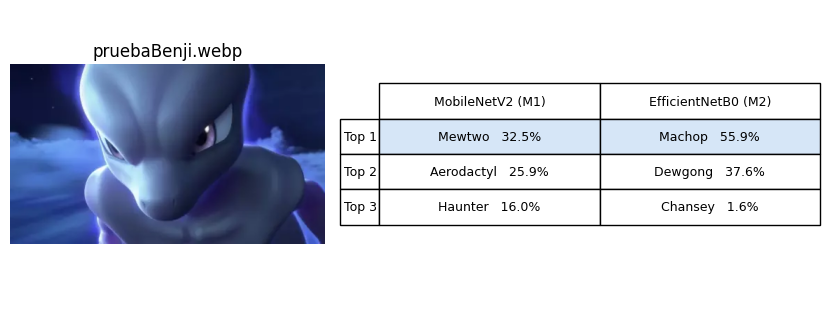

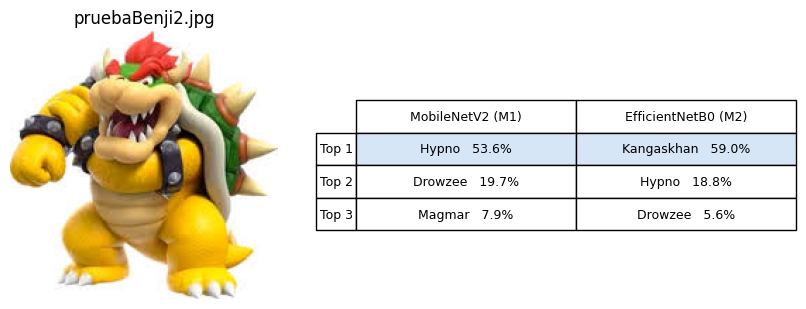

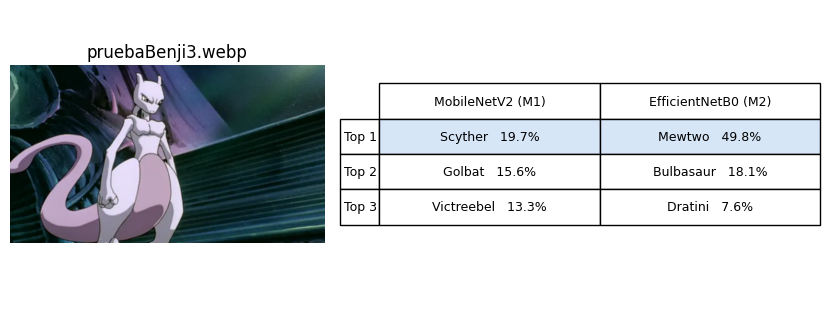

In [3]:
for ruta in benji:
    mostrar(ruta, ANTES)

## 2. Pruebas Benji — DESPUÉS de las mejoras

Las **mismas** imágenes, ahora con el **Modelo 2.0 (EfficientNetV2-S)**. El *label smoothing* hace que
las probabilidades estén mejor calibradas (menos sobreconfianza en imágenes ambiguas).

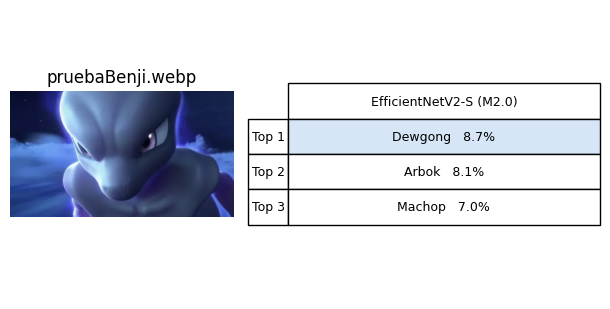

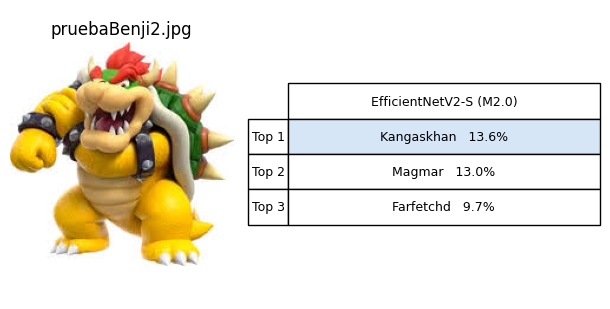

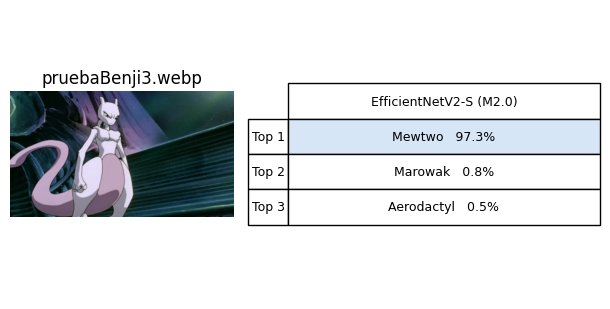

In [4]:
for ruta in benji:
    mostrar(ruta, DESPUES)

## 3. Pruebas generales (otras imágenes)

Resto de imágenes de `test_images/` (sin las Benji), con los tres modelos lado a lado.

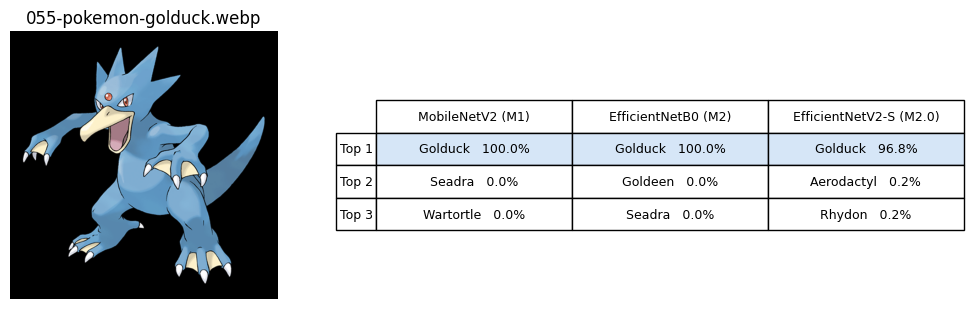

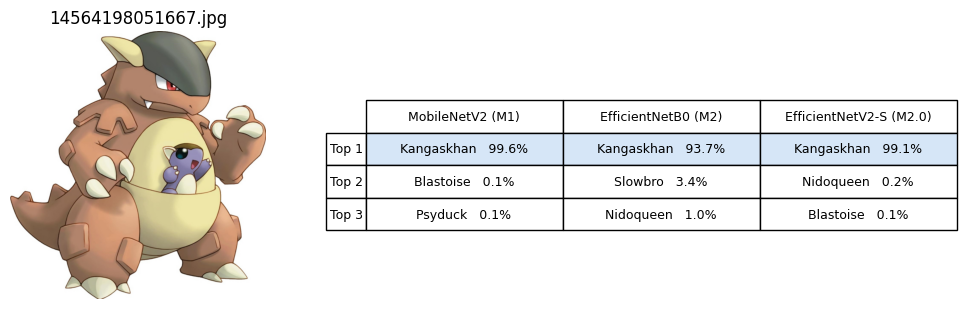

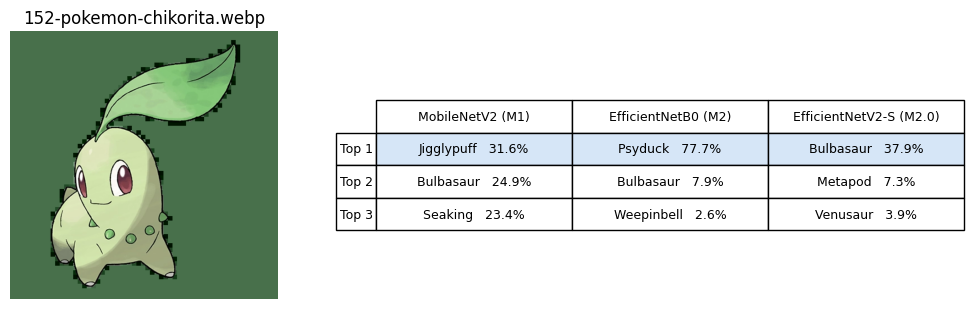

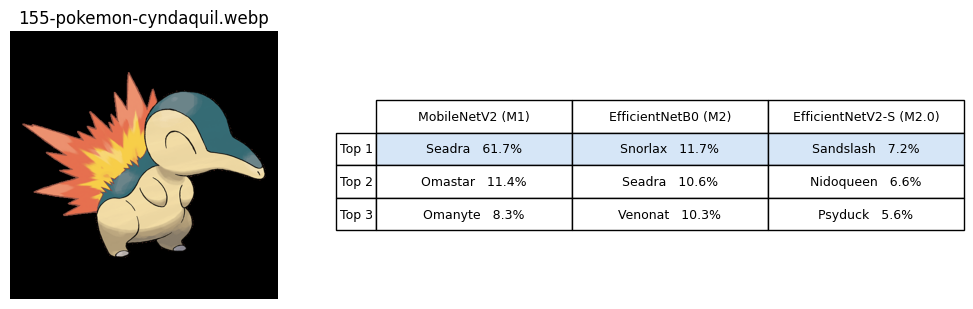

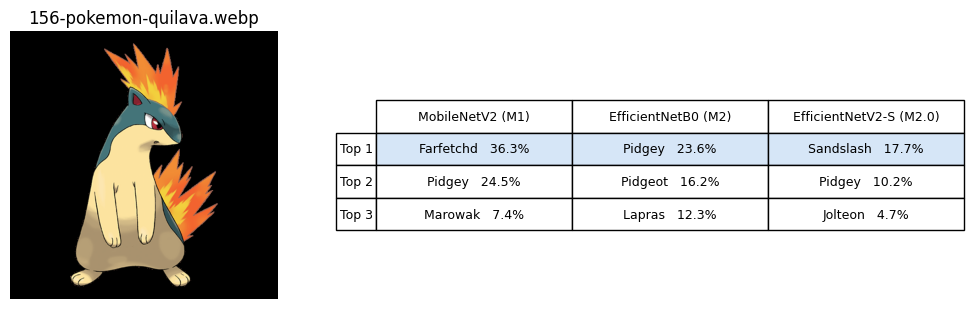

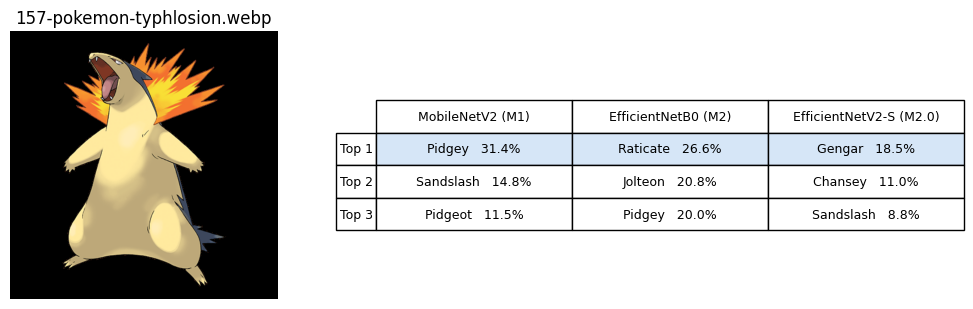

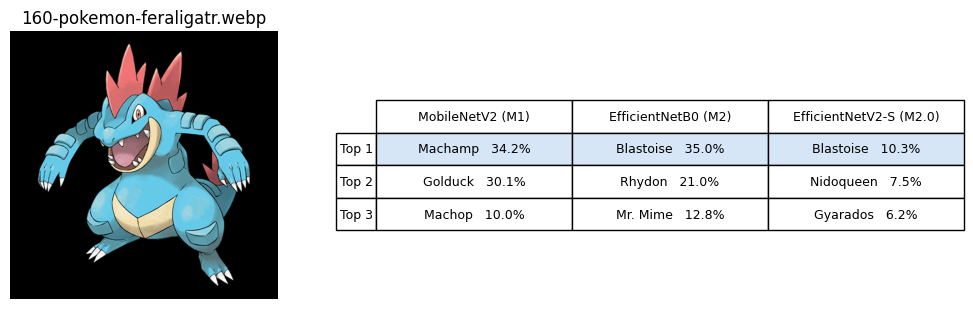

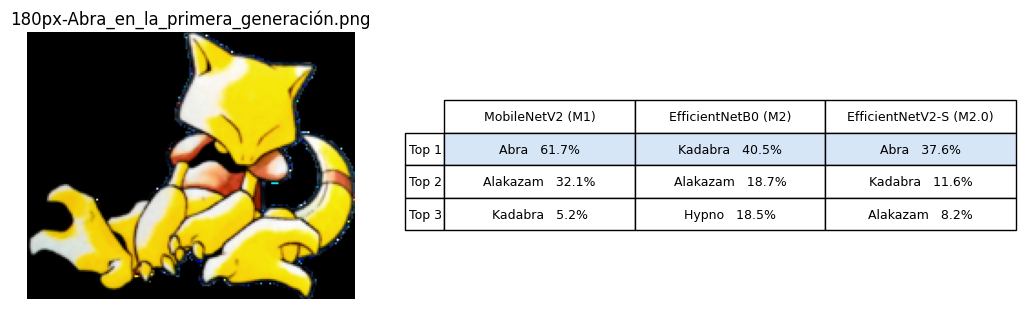

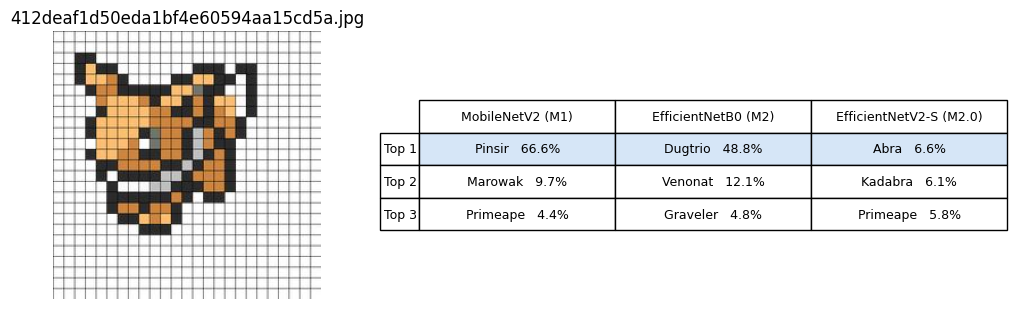

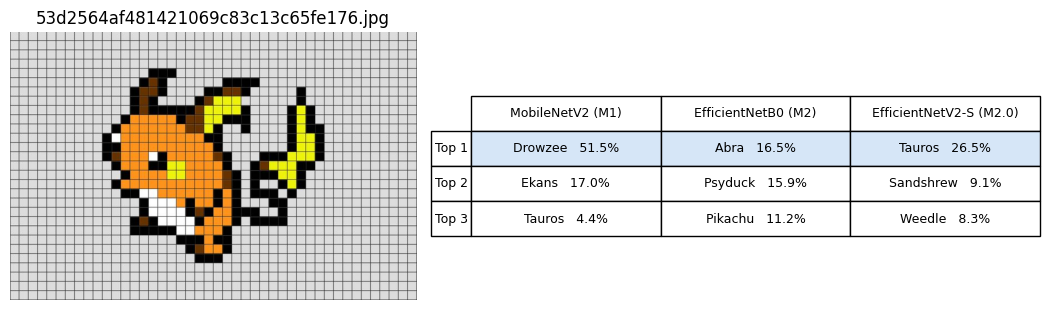

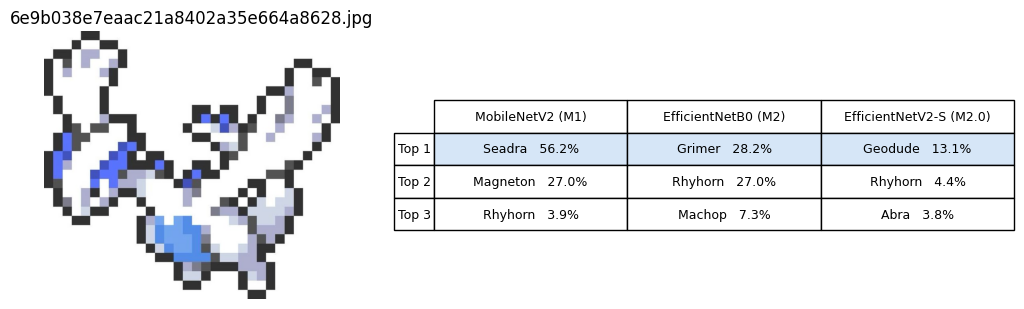

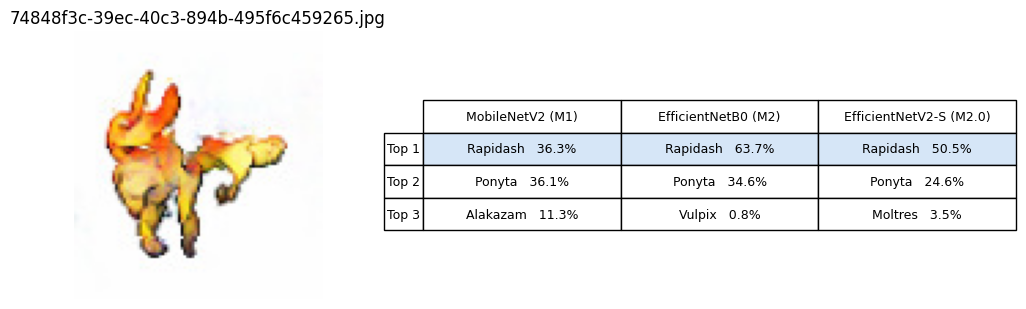

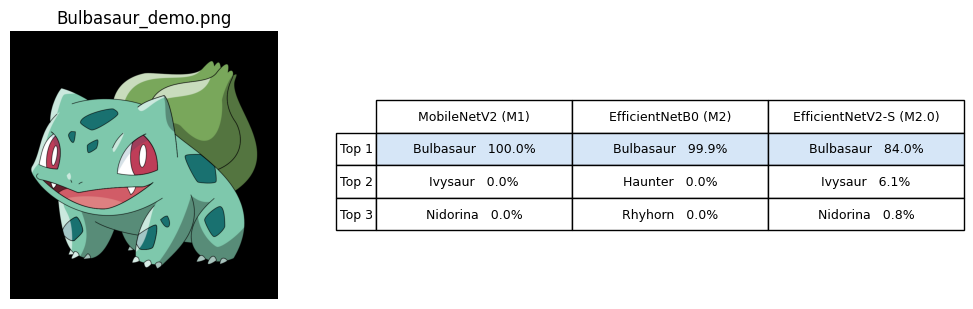

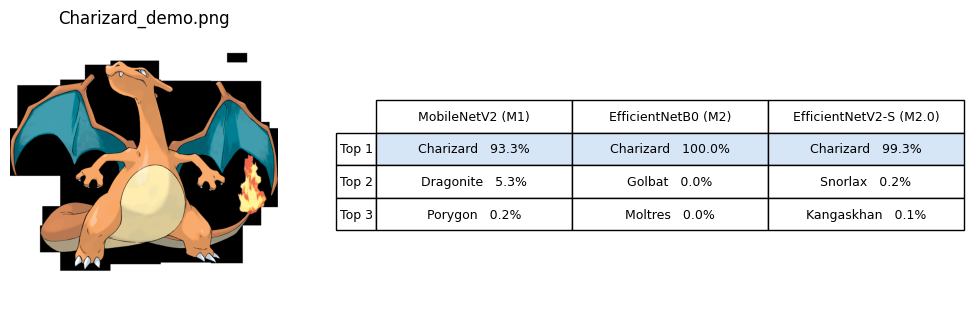

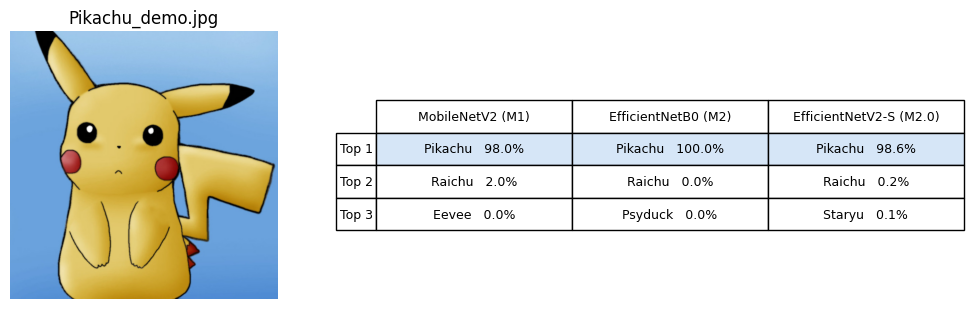

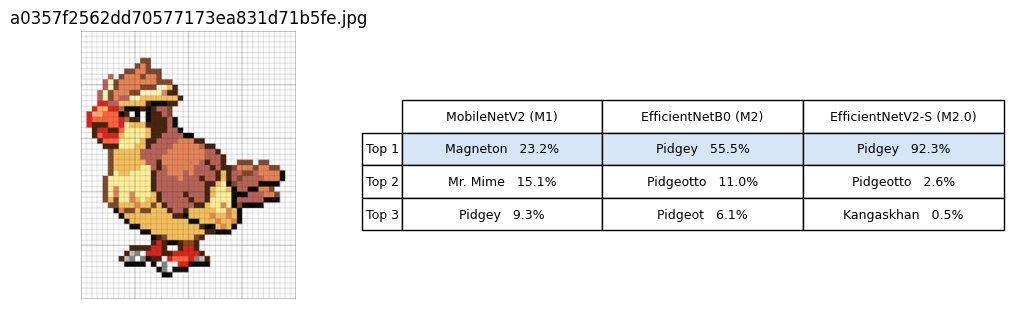

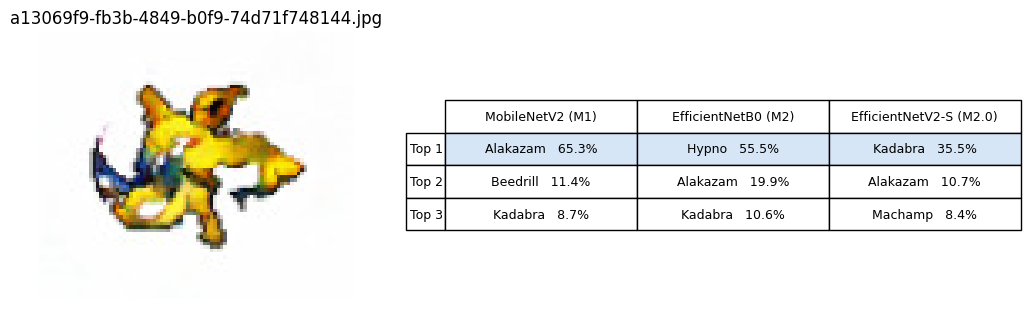

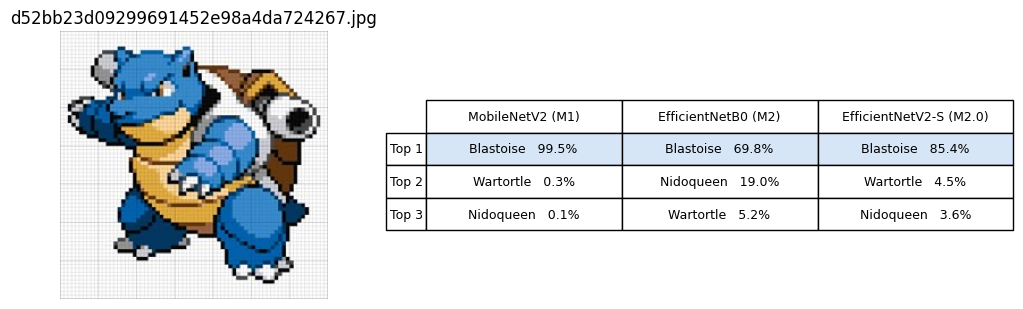

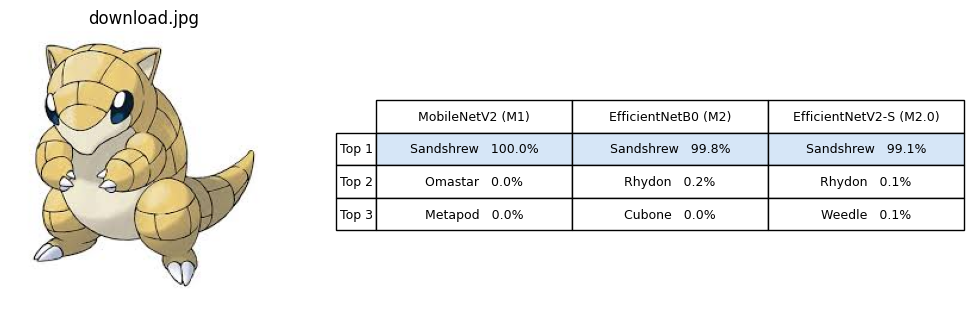

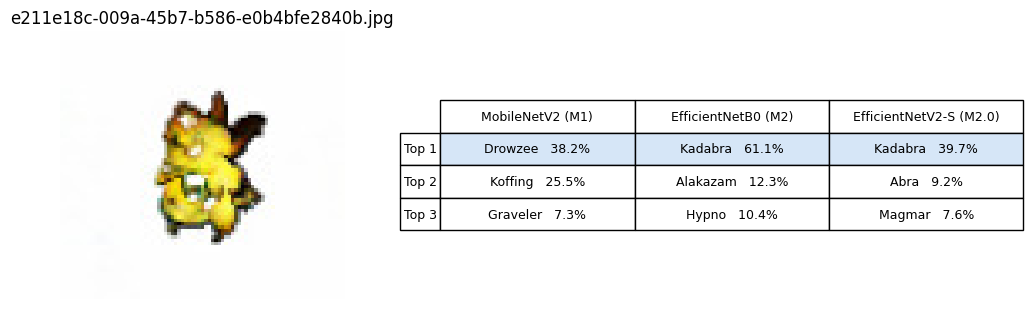

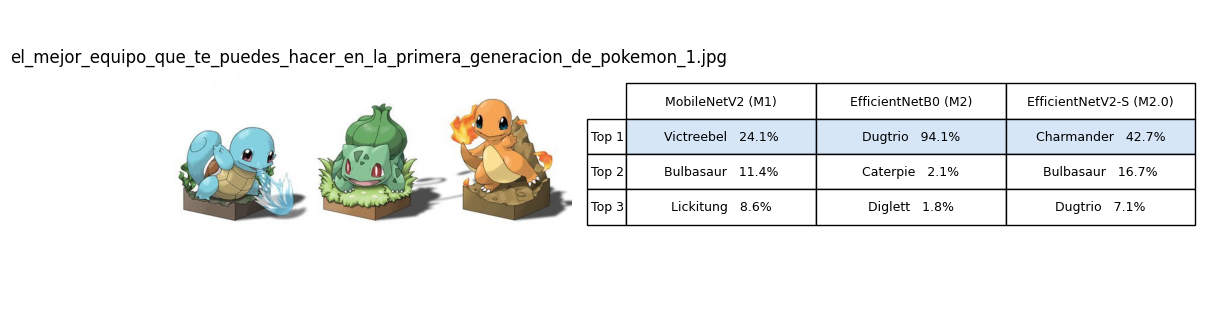

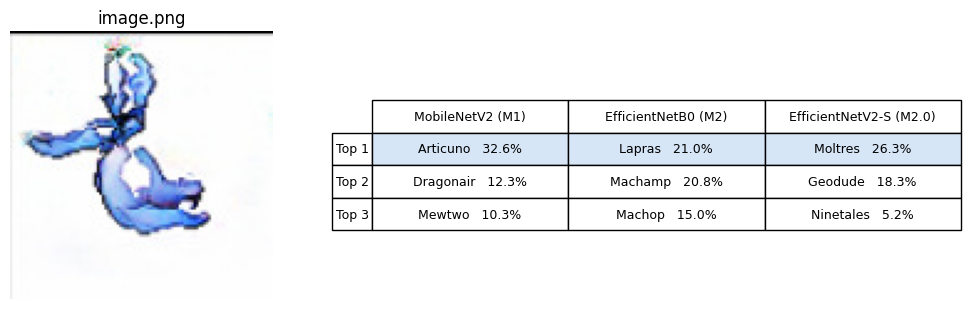

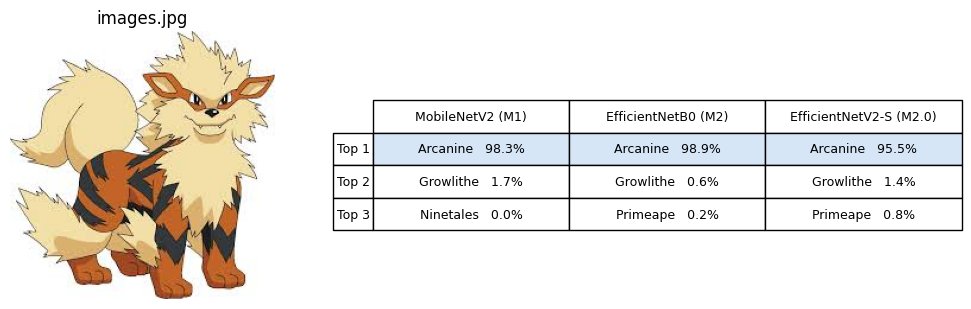

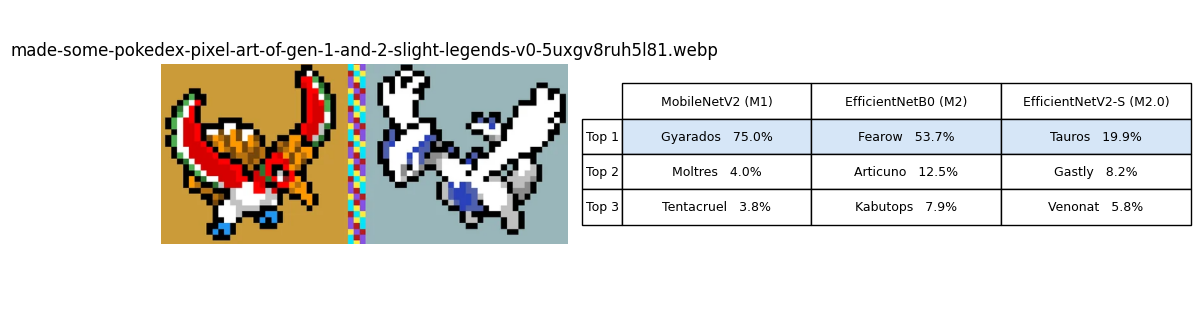

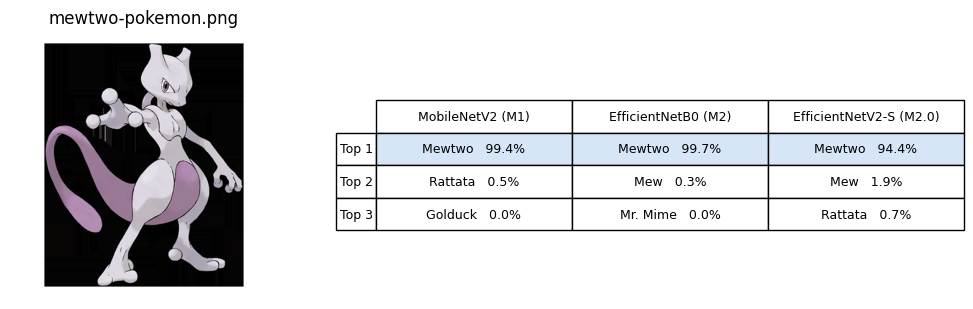

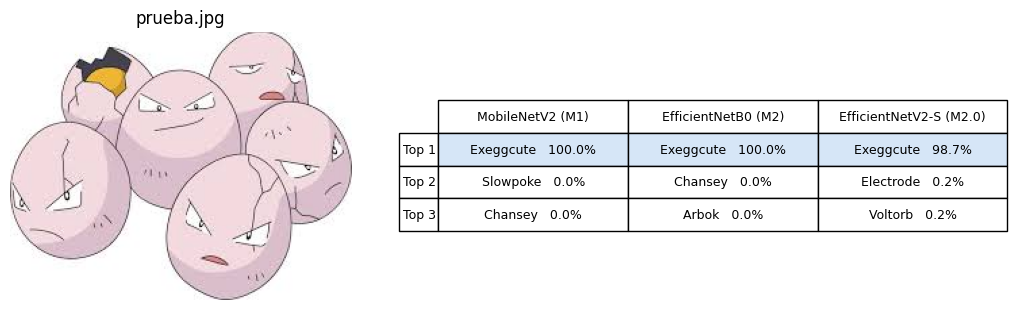

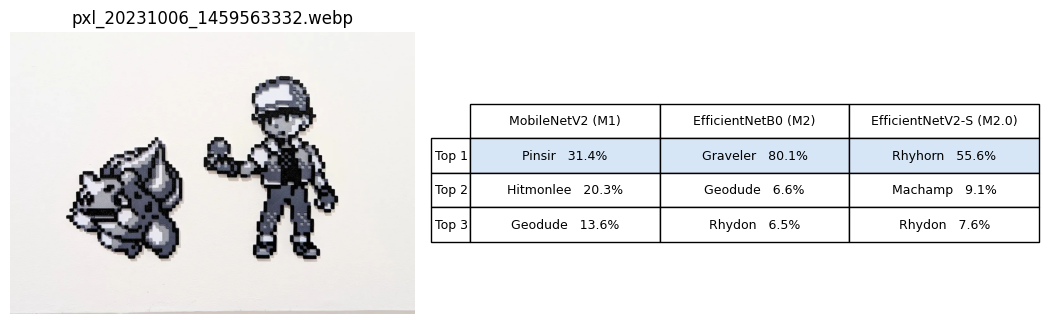

In [5]:
for ruta in otras:
    mostrar(ruta, TODOS)